In [1]:
import pandas as pd
train = pd.read_csv("/Users/ruaczcf/Downloads/room-matching-tbank-2026/public_dataset.csv")
test = pd.read_csv("/Users/ruaczcf/Downloads/room-matching-tbank-2026/new_submission_sample (3).csv")
test = test.rename(columns={"Unnamed: 0": "row_id"})

### Первая версия модели

In [4]:
import pandas as pd
import numpy as np
import re

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# =========================
# 2. Basic preprocessing
# =========================
def normalize(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train["supplier_room_name"] = train["supplier_room_name"].fillna("")
test["supplier_room_name"] = test["supplier_room_name"].fillna("")

train["name_norm"] = train["supplier_room_name"].apply(normalize)
test["name_norm"] = test["supplier_room_name"].apply(normalize)

train["hotel_id"] = train["hotel_id"].astype(str)
test["hotel_id"] = test["hotel_id"].astype(str)

# =========================
# 3. Handcrafted text features
# =========================
SERVICE_WORDS = {
    "non", "refundable", "included", "extra", "arrival", "assigned",
    "meal", "child", "children", "bed", "beds",
    "не", "включено", "дополнительная", "дополнительные", "детей",
    "кровать", "кровати", "завтрак", "питание"
}

ROOM_WORDS = {
    "room", "suite", "family", "standard", "deluxe", "single", "double", "twin",
    "номер", "люкс", "семейный", "стандарт", "делюкс", "апартаменты",
    "джуниор", "комфорт", "студия"
}

KEYWORDS = [
    "non", "refundable", "arrival", "assigned", "included", "extra",
    "breakfast", "meal", "bed", "beds",
    "не", "включено", "дополнительная", "завтрак", "питание"
]

def unique_ratio(text):
    words = text.split()
    if len(words) == 0:
        return 0.0
    return len(set(words)) / len(words)

def count_words_from_dict(text, word_set):
    words = text.split()
    return sum(w in word_set for w in words)

def first_paren_len(text):
    m = re.search(r"\((.*?)\)", text)
    if m:
        return len(m.group(1))
    return 0

def build_features(df):
    out = pd.DataFrame(index=df.index)

    out["word_count"] = df["name_norm"].str.split().str.len()
    out["char_count"] = df["name_norm"].str.len()
    out["paren_count"] = df["name_norm"].str.count(r"\(")

    out["has_number"] = df["name_norm"].str.contains(r"\d", regex=True).astype(int)
    out["has_latin"] = df["name_norm"].str.contains(r"[a-z]", regex=True).astype(int)
    out["has_cyrillic"] = df["name_norm"].str.contains(r"[а-яё]", regex=True).astype(int)

    out["unique_ratio"] = df["name_norm"].apply(unique_ratio)
    out["service_word_count"] = df["name_norm"].apply(lambda x: count_words_from_dict(x, SERVICE_WORDS))
    out["room_word_count"] = df["name_norm"].apply(lambda x: count_words_from_dict(x, ROOM_WORDS))
    out["paren_len"] = df["name_norm"].apply(first_paren_len)

    out["service_ratio"] = out["service_word_count"] / out["word_count"].clip(lower=1)

    for w in KEYWORDS:
        safe_col = f"kw_{w}"
        out[safe_col] = df["name_norm"].str.contains(re.escape(w), regex=True).astype(int)

    return out

X_train_tab = build_features(train)
X_test_tab = build_features(test)

# =========================
# 4. Hotel-level features
# =========================
# 1. Приводим hotel_id к одному типу
train["hotel_id"] = train["hotel_id"].astype(str)
test["hotel_id"] = test["hotel_id"].astype(str)

# 2. Удаляем старые hotel-level колонки, если они уже есть
hotel_cols = [
    "hotel_room_count",
    "hotel_unique_names",
    "hotel_avg_word_count",
    "hotel_avg_char_count",
]

train = train.drop(columns=[c for c in train.columns if c in hotel_cols or c.endswith("_x") or c.endswith("_y")], errors="ignore")
test = test.drop(columns=[c for c in test.columns if c in hotel_cols or c.endswith("_x") or c.endswith("_y")], errors="ignore")

# 3. Собираем hotel stats заново
hotel_stats = (
    train.groupby("hotel_id")
    .agg(
        hotel_room_count=("supplier_room_name", "size"),
        hotel_unique_names=("name_norm", "nunique"),
        hotel_avg_word_count=("name_norm", lambda s: s.str.split().str.len().mean()),
        hotel_avg_char_count=("name_norm", lambda s: s.str.len().mean()),
    )
    .reset_index()
)

print("hotel_stats columns:", hotel_stats.columns.tolist())

# 4. Merge
train = train.merge(hotel_stats, on="hotel_id", how="left")
test = test.merge(hotel_stats, on="hotel_id", how="left")

print("train columns after merge:", [c for c in train.columns if c.startswith("hotel_")])

# 5. Fill missing
for col in hotel_cols:
    fill_value = train[col].mean()
    train[col] = train[col].fillna(fill_value)
    test[col] = test[col].fillna(fill_value)

X_train_tab["hotel_room_count"] = train["hotel_room_count"].values
X_train_tab["hotel_unique_names"] = train["hotel_unique_names"].values
X_train_tab["hotel_avg_word_count"] = train["hotel_avg_word_count"].values
X_train_tab["hotel_avg_char_count"] = train["hotel_avg_char_count"].values

X_test_tab["hotel_room_count"] = test["hotel_room_count"].values
X_test_tab["hotel_unique_names"] = test["hotel_unique_names"].values
X_test_tab["hotel_avg_word_count"] = test["hotel_avg_word_count"].values
X_test_tab["hotel_avg_char_count"] = test["hotel_avg_char_count"].values

# =========================
# 5. Sentence embeddings
# =========================
embed_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

train_emb = embed_model.encode(
    train["name_norm"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

test_emb = embed_model.encode(
    test["name_norm"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings:", train_emb.shape, test_emb.shape)

# =========================
# 6. Scale tabular features and combine
# =========================
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

X_train_full = np.hstack([train_emb, X_train_tab_scaled])
X_test_full = np.hstack([test_emb, X_test_tab_scaled])

y = train["target"].astype(int).values

print("Final train shape:", X_train_full.shape)
print("Final test shape:", X_test_full.shape)

# =========================
# 7. Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 8. Train LightGBM
# =========================
model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(X_tr, y_tr)

val_pred = model.predict_proba(X_val)[:, 1]
pr_auc = average_precision_score(y_val, val_pred)
print("Validation PR-AUC:", pr_auc)

# =========================
# 9. Train on full train
# =========================
model.fit(X_train_full, y)

# =========================
# 10. Predict test
# =========================
test_pred = model.predict_proba(X_test_full)[:, 1]

submission = test[["row_id"]].copy()
submission["target"] = test_pred

# if competition wants hard labels:
# submission["target"] = (test_pred > 0.5).astype(int)

submission.to_csv("submission.csv", index=False)
print(submission.head())
print("Saved to submission.csv")

hotel_stats columns: ['hotel_id', 'hotel_room_count', 'hotel_unique_names', 'hotel_avg_word_count', 'hotel_avg_char_count']
train columns after merge: ['hotel_id', 'hotel_room_count', 'hotel_unique_names', 'hotel_avg_word_count', 'hotel_avg_char_count']


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9395.27it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 86/86 [00:04<00:00, 20.27it/s]


Embeddings: (184138, 384) (11000, 384)
Final train shape: (184138, 414)
Final test shape: (11000, 414)
[LightGBM] [Info] Number of positive: 76002, number of negative: 71308
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 99641
[LightGBM] [Info] Number of data points in the train set: 147310, number of used features: 414
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515932 -> initscore=0.063751
[LightGBM] [Info] Start training from score 0.063751


/Users/ruaczcf/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation PR-AUC: 0.9318310459229963
[LightGBM] [Info] Number of positive: 95003, number of negative: 89135
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051841 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 99646
[LightGBM] [Info] Number of data points in the train set: 184138, number of used features: 414
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515934 -> initscore=0.063756
[LightGBM] [Info] Start training from score 0.063756
   row_id    target
0       0  0.173901
1       1  0.720320
2       2  0.940507
3       3  0.978627
4       4  0.010425
Saved to submission.csv


/Users/ruaczcf/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Добавляем фичи по тексту, которые показывают вероятность тексту быть отклоненным

In [5]:
# =========================
# 11. Add stronger features AFTER embeddings
# =========================
from collections import defaultdict
import numpy as np

# ---------- 11.1 text prior / text count ----------
global_mean = train["target"].mean()

text_prior = train.groupby("name_norm")["target"].mean()
text_count = train.groupby("name_norm")["target"].count()

X_train_tab["text_prior"] = train["name_norm"].map(text_prior)
X_test_tab["text_prior"] = test["name_norm"].map(text_prior)

X_train_tab["text_count"] = train["name_norm"].map(text_count)
X_test_tab["text_count"] = test["name_norm"].map(text_count)

X_train_tab["text_prior"] = X_train_tab["text_prior"].fillna(global_mean)
X_test_tab["text_prior"] = X_test_tab["text_prior"].fillna(global_mean)

X_train_tab["text_count"] = X_train_tab["text_count"].fillna(0)
X_test_tab["text_count"] = X_test_tab["text_count"].fillna(0)

# optional interaction
X_train_tab["text_prior_x_count"] = X_train_tab["text_prior"] * np.log1p(X_train_tab["text_count"])
X_test_tab["text_prior_x_count"] = X_test_tab["text_prior"] * np.log1p(X_test_tab["text_count"])


# ---------- 11.2 token prior features ----------
token_sum = defaultdict(float)
token_cnt = defaultdict(int)

for text, target in zip(train["name_norm"], train["target"]):
    for w in set(text.split()):
        token_sum[w] += target
        token_cnt[w] += 1

token_prior_dict = {w: token_sum[w] / token_cnt[w] for w in token_sum}

def token_prior_mean(text):
    words = text.split()
    if not words:
        return global_mean
    vals = [token_prior_dict.get(w, global_mean) for w in words]
    return float(np.mean(vals))

def token_prior_max(text):
    words = text.split()
    if not words:
        return global_mean
    vals = [token_prior_dict.get(w, global_mean) for w in words]
    return float(np.max(vals))

def token_prior_min(text):
    words = text.split()
    if not words:
        return global_mean
    vals = [token_prior_dict.get(w, global_mean) for w in words]
    return float(np.min(vals))

X_train_tab["token_prior_mean"] = train["name_norm"].apply(token_prior_mean)
X_test_tab["token_prior_mean"] = test["name_norm"].apply(token_prior_mean)

X_train_tab["token_prior_max"] = train["name_norm"].apply(token_prior_max)
X_test_tab["token_prior_max"] = test["name_norm"].apply(token_prior_max)

X_train_tab["token_prior_min"] = train["name_norm"].apply(token_prior_min)
X_test_tab["token_prior_min"] = test["name_norm"].apply(token_prior_min)


# ---------- 11.3 safe centroid similarity ----------
# embeddings already exist: train_emb, test_emb
train_emb64 = np.asarray(train_emb, dtype=np.float64)
test_emb64 = np.asarray(test_emb, dtype=np.float64)
y_arr = train["target"].astype(int).values

pos_centroid = train_emb64[y_arr == 1].mean(axis=0)
neg_centroid = train_emb64[y_arr == 0].mean(axis=0)

def normalize_vec(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        return v
    return v / norm

pos_centroid = normalize_vec(pos_centroid)
neg_centroid = normalize_vec(neg_centroid)

X_train_tab["sim_pos_centroid"] = np.sum(train_emb64 * pos_centroid, axis=1)
X_train_tab["sim_neg_centroid"] = np.sum(train_emb64 * neg_centroid, axis=1)
X_train_tab["sim_margin"] = X_train_tab["sim_pos_centroid"] - X_train_tab["sim_neg_centroid"]

X_test_tab["sim_pos_centroid"] = np.sum(test_emb64 * pos_centroid, axis=1)
X_test_tab["sim_neg_centroid"] = np.sum(test_emb64 * neg_centroid, axis=1)
X_test_tab["sim_margin"] = X_test_tab["sim_pos_centroid"] - X_test_tab["sim_neg_centroid"]


# ---------- 11.4 optional extra interaction ----------
X_train_tab["service_minus_room"] = X_train_tab["service_word_count"] - X_train_tab["room_word_count"]
X_test_tab["service_minus_room"] = X_test_tab["service_word_count"] - X_test_tab["room_word_count"]


# =========================
# 12. Rebuild scaled tabular matrices
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

# embeddings + new tabular features
X_train_full = np.hstack([train_emb, X_train_tab_scaled])
X_test_full = np.hstack([test_emb, X_test_tab_scaled])

y = train["target"].astype(int).values

print("New train shape:", X_train_full.shape)
print("New test shape:", X_test_full.shape)


# =========================
# 13. New validation split
# =========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 14. Retrain LightGBM
# =========================
import lightgbm as lgb

model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1200,
    learning_rate=0.025,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_tr, y_tr)

val_pred = model.predict_proba(X_val)[:, 1]
pr_auc = average_precision_score(y_val, val_pred)
print("Validation PR-AUC (improved features):", pr_auc)


# =========================
# 15. Fit on full train
# =========================
model.fit(X_train_full, y)


# =========================
# 16. Predict test and save
# =========================
test_pred = model.predict_proba(X_test_full)[:, 1]

submission = test[["row_id"]].copy()
submission["target"] = test_pred
submission.to_csv("submission_v2.csv", index=False)

print(submission.head())
print("Saved to submission_v2.csv")

New train shape: (184138, 424)
New test shape: (11000, 424)
[LightGBM] [Info] Number of positive: 76002, number of negative: 71308
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101614
[LightGBM] [Info] Number of data points in the train set: 147310, number of used features: 424
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515932 -> initscore=0.063751
[LightGBM] [Info] Start training from score 0.063751


/Users/ruaczcf/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation PR-AUC (improved features): 0.9971590493401464
[LightGBM] [Info] Number of positive: 95003, number of negative: 89135
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046295 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101620
[LightGBM] [Info] Number of data points in the train set: 184138, number of used features: 424
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515934 -> initscore=0.063756
[LightGBM] [Info] Start training from score 0.063756
   row_id    target
0       0  0.191452
1       1  0.480869
2       2  0.327633
3       3  0.999989
4       4  0.022900
Saved to submission_v2.csv


/Users/ruaczcf/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Сверху были вероятности для текстов, пытаемся учесть отель

In [6]:
from collections import defaultdict

# ====================================================
# FUZZY WITHIN-HOTEL TOKEN MATCHING
# Идея: для каждой комнаты найти наиболее похожую
# комнату из трейна в том же отеле по Jaccard токенов.
# Фичи: best_jaccard, best_target (LOO для трейна),
#        is_subset, is_superset
# ====================================================

def tokenize(text):
    return set(re.sub(r'[^\w]', ' ', str(text)).split())

def jaccard(a, b):
    if not a and not b:
        return 1.0
    union = a | b
    return len(a & b) / len(union) if union else 0.0

# Индекс: hotel_id -> list of {tokens, target, idx}
hotel_train_index = defaultdict(list)
for i, row in train.iterrows():
    hotel_train_index[row["hotel_id"]].append({
        "tokens": tokenize(row["name_norm"]),
        "target": row["target"],
        "idx": i,
    })

def compute_fuzzy(hotel_id, tokens, exclude_idx=None, fallback=None):
    candidates = hotel_train_index.get(hotel_id, [])
    best_jac, best_tgt = 0.0, fallback
    is_sub, is_sup = 0, 0
    for c in candidates:
        if exclude_idx is not None and c["idx"] == exclude_idx:
            continue
        j = jaccard(tokens, c["tokens"])
        if j > best_jac:
            best_jac, best_tgt = j, c["target"]
        if tokens and tokens <= c["tokens"]:   # tokens ⊆ candidate
            is_sub = 1
        if c["tokens"] and c["tokens"] <= tokens:  # candidate ⊆ tokens
            is_sup = 1
    return best_jac, best_tgt, is_sub, is_sup

global_mean_target = train["target"].mean()

# --- Train: Leave-One-Out ---
fuzzy_tr = [
    compute_fuzzy(
        row["hotel_id"],
        tokenize(row["name_norm"]),
        exclude_idx=i,
        fallback=global_mean_target,
    )
    for i, row in train.iterrows()
]

# --- Test: все записи трейна ---
fuzzy_te = [
    compute_fuzzy(
        row["hotel_id"],
        tokenize(row["name_norm"]),
        fallback=global_mean_target,
    )
    for _, row in test.iterrows()
]

cols = ["fuzzy_jaccard", "fuzzy_target", "fuzzy_is_subset", "fuzzy_is_superset"]
fuzzy_tr_df = pd.DataFrame(fuzzy_tr, columns=cols, index=train.index)
fuzzy_te_df = pd.DataFrame(fuzzy_te, columns=cols, index=test.index)

# диагностика
exact = (fuzzy_te_df["fuzzy_jaccard"] == 1.0).sum()
near  = (fuzzy_te_df["fuzzy_jaccard"] >= 0.8).sum()
print(f"Test exact matches (j=1.0): {exact}/{len(test)} ({100*exact/len(test):.1f}%)")
print(f"Test near  matches (j≥0.8): {near}/{len(test)} ({100*near/len(test):.1f}%)")

# ====================================================
# Добавляем к существующему X_train_tab / X_test_tab
# (считаем что они уже построены выше)
# ====================================================
X_train_tab_v3 = X_train_tab.copy()
X_test_tab_v3  = X_test_tab.copy()

for col in cols:
    X_train_tab_v3[col] = fuzzy_tr_df[col].values
    X_test_tab_v3[col]  = fuzzy_te_df[col].values

print("New feature columns:", cols)

# ====================================================
# Rescale + combine
# ====================================================
scaler_v3 = StandardScaler()
X_tr_tab_s = scaler_v3.fit_transform(X_train_tab_v3)
X_te_tab_s = scaler_v3.transform(X_test_tab_v3)

X_train_v3 = np.hstack([train_emb, X_tr_tab_s])
X_test_v3  = np.hstack([test_emb,  X_te_tab_s])

print("Train shape:", X_train_v3.shape)
print("Test  shape:", X_test_v3.shape)

# ====================================================
# Валидация — random split (консистентен с baseline)
# ====================================================
X_tr3, X_val3, y_tr3, y_val3 = train_test_split(
    X_train_v3, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model_v3 = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

model_v3.fit(X_tr3, y_tr3)
val_pred_v3 = model_v3.predict_proba(X_val3)[:, 1]
pr_auc_v3   = average_precision_score(y_val3, val_pred_v3)
print(f"v3  PR-AUC: {pr_auc_v3:.4f}")
print(f"v1  PR-AUC: {pr_auc:.4f}  (baseline)")

# ====================================================
# Обучение на полном трейне + сабмит
# ====================================================
model_v3.fit(X_train_v3, y)
test_pred_v3 = model_v3.predict_proba(X_test_v3)[:, 1]

submission_v3 = test[["row_id"]].copy()
submission_v3["target"] = test_pred_v3
submission_v3.to_csv("submission_v3.csv", index=False)
print(submission_v3.head())
print("Saved → submission_v3.csv")


Test exact matches (j=1.0): 4555/11000 (41.4%)
Test near  matches (j≥0.8): 7576/11000 (68.9%)
New feature columns: ['fuzzy_jaccard', 'fuzzy_target', 'fuzzy_is_subset', 'fuzzy_is_superset']
Train shape: (184138, 428)
Test  shape: (11000, 428)
[LightGBM] [Info] Number of positive: 76002, number of negative: 71308
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101746
[LightGBM] [Info] Number of data points in the train set: 147310, number of used features: 428
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515932 -> initscore=0.063751
[LightGBM] [Info] Start training from score 0.063751


/Users/ruaczcf/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


v3  PR-AUC: 0.9980
v1  PR-AUC: 0.9972  (baseline)
[LightGBM] [Info] Number of positive: 95003, number of negative: 89135
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051998 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101753
[LightGBM] [Info] Number of data points in the train set: 184138, number of used features: 428
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515934 -> initscore=0.063756
[LightGBM] [Info] Start training from score 0.063756
   row_id    target
0       0  0.178127
1       1  0.780610
2       2  0.285608
3       3  0.999981
4       4  0.007018
Saved → submission_v3.csv


/Users/ruaczcf/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Смотрим на метрики

In [7]:
# ====================================================
# PR-КРИВАЯ В СТИЛЕ Т-БАНКА
# ====================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patheffects import withStroke
from sklearn.metrics import precision_recall_curve

precision_arr, recall_arr, _ = precision_recall_curve(y_val3, val_pred_v3)
baseline = np.mean(y_val3)

mask = precision_arr[:-1] >= 0.95
if mask.any():
    r95 = float(recall_arr[:-1][mask].max())
    best_idx = int(np.where((recall_arr[:-1] == r95) & mask)[0][-1])
    p95 = float(precision_arr[best_idx])
else:
    r95, p95 = 0.0, 0.95

print(f"PR-AUC: {pr_auc_v3:.4f} | Recall @ P>=95%: {r95:.4f}")

step = max(1, len(precision_arr) // 1000)
rec  = recall_arr[::step]
prec = precision_arr[::step]

BG, YELLOW, WHITE, GRID, MUTED = '#111111', '#FFDD2D', '#FFFFFF', '#1E1E1E', '#888888'

fig = plt.figure(figsize=(13, 7), facecolor=BG)

# Главный график — оставляем место справа под карточки
ax = fig.add_axes([0.07, 0.13, 0.67, 0.72], facecolor=BG)

for gv in np.arange(0.5, 1.05, 0.1):
    ax.axhline(gv, color=GRID, lw=0.8, zorder=0)
for gh in np.arange(0.0, 1.05, 0.2):
    ax.axvline(gh, color=GRID, lw=0.8, zorder=0)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(0.44, 1.02)

ax.axhline(baseline, color='#3A3A3A', lw=1.3, ls='--', zorder=1)
ax.text(0.50, baseline + 0.013, f'Случайный классификатор ({baseline:.2f})',
        color='#444', fontsize=8.5, ha='center')

ax.fill_between(rec, baseline, prec, alpha=0.10, color=YELLOW, zorder=2)

for lw_, a_ in [(16, 0.04), (9, 0.09), (4, 0.16)]:
    ax.plot(rec, prec, color=YELLOW, lw=lw_, alpha=a_, solid_capstyle='round', zorder=3)
ax.plot(rec, prec, color=YELLOW, lw=2.5, solid_capstyle='round', zorder=4)

# Пунктирные линии к точке
ax.plot([r95, r95], [0.44, p95], color='#555', lw=1.0, ls=':', zorder=3)
ax.plot([-0.01, r95], [p95, p95], color='#555', lw=1.0, ls=':', zorder=3)

# Ключевая точка
for s_, a_ in [(260, 0.08), (90, 0.18)]:
    ax.scatter([r95], [p95], s=s_, color=YELLOW, alpha=a_, zorder=5)
ax.scatter([r95], [p95], s=50, color=YELLOW, zorder=6, edgecolors=WHITE, linewidths=1.8)

# Подпись — всегда LEFT от точки, чуть ниже
label_x = max(0.05, r95 - 0.32)
label_y = p95 - 0.05
ax.annotate(
    f'Recall = {r95:.1%}\nPrecision = {p95:.1%}',
    xy=(r95, p95),
    xytext=(label_x, label_y),
    color=YELLOW,
    fontsize=9,
    ha='center',
    va='top',
    arrowprops=dict(arrowstyle='-', color='#555', lw=0.8),
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#1C1C1C',
              edgecolor=YELLOW, linewidth=1.0),
    zorder=8,
)

ax.tick_params(colors=MUTED, labelsize=10.5, length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_xlabel('Recall',    color=MUTED, fontsize=12, labelpad=10)
ax.set_ylabel('Precision', color=MUTED, fontsize=12, labelpad=10)
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%','20%','40%','60%','80%','100%'], color=MUTED)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['50%','60%','70%','80%','90%','100%'], color=MUTED)

# ── Карточка 1: PR-AUC (верхняя) ──────────────────────────────
cax1 = fig.add_axes([0.78, 0.52, 0.18, 0.33], facecolor=BG)
cax1.set_xlim(0, 1); cax1.set_ylim(0, 1); cax1.axis('off')
c1 = patches.FancyBboxPatch((0.04, 0.06), 0.92, 0.88,
     boxstyle="round,pad=0.04", lw=1.5, edgecolor=YELLOW, facecolor='#1C1C1C')
cax1.add_patch(c1)
cax1.text(0.50, 0.80, 'PR-AUC', ha='center', color=MUTED, fontsize=9.5, fontweight='bold')
cax1.text(0.50, 0.42, f'{pr_auc_v3:.4f}', ha='center', color=YELLOW, fontsize=26, fontweight='bold',
          path_effects=[withStroke(linewidth=4, foreground='#1C1C1C')])

# ── Карточка 2: Recall@95% (нижняя) ───────────────────────────
cax2 = fig.add_axes([0.78, 0.13, 0.18, 0.33], facecolor=BG)
cax2.set_xlim(0, 1); cax2.set_ylim(0, 1); cax2.axis('off')
c2 = patches.FancyBboxPatch((0.04, 0.06), 0.92, 0.88,
     boxstyle="round,pad=0.04", lw=1.2, edgecolor='#333', facecolor='#1C1C1C')
cax2.add_patch(c2)
cax2.text(0.50, 0.80, 'Recall @ P=95%', ha='center', color=MUTED, fontsize=9, fontweight='bold')
cax2.text(0.50, 0.42, f'{r95:.3f}', ha='center', color=WHITE, fontsize=26, fontweight='bold')

# ── Заголовок ──────────────────────────────────────────────────
fig.text(0.07, 0.93,  'Precision-Recall кривая',
         ha='left', color=WHITE, fontsize=15, fontweight='bold')
fig.text(0.07, 0.885, 'Hold-out 20%  ·  LightGBM + Multilingual Embeddings + Fuzzy Match',
         ha='left', color=MUTED, fontsize=10)

plt.savefig('pr_curve_tbank.png', dpi=150, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.close()
print(f"Saved → pr_curve_tbank.png")
print(f"PR-AUC: {pr_auc_v3:.4f} | Recall @ Precision=95%: {r95:.4f}")


PR-AUC: 0.9980 | Recall @ P>=95%: 0.9920
Saved → pr_curve_tbank.png
PR-AUC: 0.9980 | Recall @ Precision=95%: 0.9920


### Смотрим на SHAP values

In [9]:
# ────────────────────────────────────────────────────────────────
# WATERFALL — с фиксом наложений f(x)/E[x] и именем комнаты в fname
# ────────────────────────────────────────────────────────────────

pred_scores = model_v3.predict_proba(X_sample)[:, 1]
idx_pos  = np.where(y_sample == 1)[0]
idx_neg  = np.where(y_sample == 0)[0]
sure_pos = idx_pos[np.argmax(pred_scores[idx_pos])]
sure_neg = idx_neg[np.argmin(pred_scores[idx_neg])]
border   = np.argmin(np.abs(pred_scores - 0.5))

# Получаем реальное название комнаты для каждого примера
def get_room_name(local_idx):
    """local_idx — индекс в X_sample (0..499)"""
    train_idx = sample_idx[local_idx]
    return str(train.iloc[train_idx]["supplier_room_name"])

cases = [
    (sure_pos, f"Уверенный target=1 · score={pred_scores[sure_pos]:.2f}",
               "не матчится · модель уверена"),
    (sure_neg, f"Уверенный target=0 · score={pred_scores[sure_neg]:.2f}",
               "матчится · модель уверена"),
    (border,   f"Пограничный случай · score={pred_scores[border]:.2f}",
               "модель сомневается"),
]


def fix_waterfall_overlaps(fig):
    """
    Исправляет наложение f(x) и E[x] подписей в shap.waterfall_plot.
    SHAP рисует их как fig.texts — ищем по содержимому и двигаем если близко.
    """
    fig.patch.set_facecolor(BG)
    for ax in fig.axes:
        ax.set_facecolor(CARD)
        for sp in ax.spines.values(): sp.set_color(BORDER)
        for txt in ax.texts:          txt.set_color(DARK)
        for txt in ax.get_xticklabels(): txt.set_color(MUTED); txt.set_fontsize(10)
        for txt in ax.get_yticklabels(): txt.set_color(DARK);  txt.set_fontsize(10.5)
        ax.xaxis.label.set_color(MUTED)
        ax.tick_params(colors=MUTED, length=0)

    # Собираем все тексты фигуры (f(x) и E[f(x)] добавляются в fig.texts)
    fig.canvas.draw()  # нужно для get_window_extent
    renderer = fig.canvas.get_renderer()

    # Находим подписи f(x) и E[f(x)] по содержимому
    annots = []
    for txt in fig.texts:
        s = txt.get_text()
        if 'f(x)' in s or 'E[f' in s:
            annots.append(txt)

    # Если обе нашли — проверяем наложение
    if len(annots) == 2:
        t0, t1 = annots[0], annots[1]
        y0 = t0.get_position()[1]
        y1 = t1.get_position()[1]
        # В координатах figure (0..1): если ближе 0.04 — разводим
        if abs(y0 - y1) < 0.045:
            mid = (y0 + y1) / 2
            offset = 0.025
            # тот что выше — двигаем вверх, тот что ниже — вниз
            if y0 >= y1:
                t0.set_position((t0.get_position()[0], mid + offset))
                t1.set_position((t1.get_position()[0], mid - offset))
            else:
                t1.set_position((t1.get_position()[0], mid + offset))
                t0.set_position((t0.get_position()[0], mid - offset))


def style_waterfall_title(fig, title, subtitle):
    """Добавляет заголовок поверх."""
    fig.text(0.04, 0.97,  title,    ha='left', color=DARK,  fontsize=13, fontweight='bold')
    fig.text(0.04, 0.935, subtitle, ha='left', color=MUTED, fontsize=9.5)


for case_idx, title, subtitle in cases:
    room_name = get_room_name(case_idx)
    # Безопасное имя файла из названия комнаты (макс 60 символов)
    safe_room = (room_name
                 .replace('/', '_').replace('\\', '_')
                 .replace(':', '').replace('"', '')
                 .replace('*', '').replace('?', '')
                 .replace('<', '').replace('>', '').replace('|', '')
                 .strip())[:60]

    for feat_names, suffix in [
        (tab_names, "имена"),
        (tab_descs, "описания"),
    ]:
        shap_exp = shap.Explanation(
            values        = sv_tab[case_idx],
            base_values   = base_val,
            data          = X_sample[case_idx, emb_dim:],
            feature_names = feat_names,
        )

        plt.figure(figsize=(13, 6.5))
        shap.waterfall_plot(shap_exp, max_display=12, show=False)
        fig = plt.gcf()

        fix_waterfall_overlaps(fig)            # ← фиксим f(x)/E[x]
        style_waterfall_title(fig, title, subtitle)

        # Подпись с названием комнаты внизу
        fig.text(0.04, 0.01,
                 f'Комната: «{room_name[:80]}»',
                 ha='left', color=MUTED, fontsize=8.5,
                 style='italic')

        plt.tight_layout(rect=[0, 0.04, 1, 0.92])

        fname = f"shap_waterfall_{safe_room}_{suffix}.png"
        plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
        plt.close()
        print(f"Saved → {fname}")
        print(f"  room: «{room_name}»")

print("\n✓ Waterfall-графики сохранены.")


NameError: name 'X_sample' is not defined

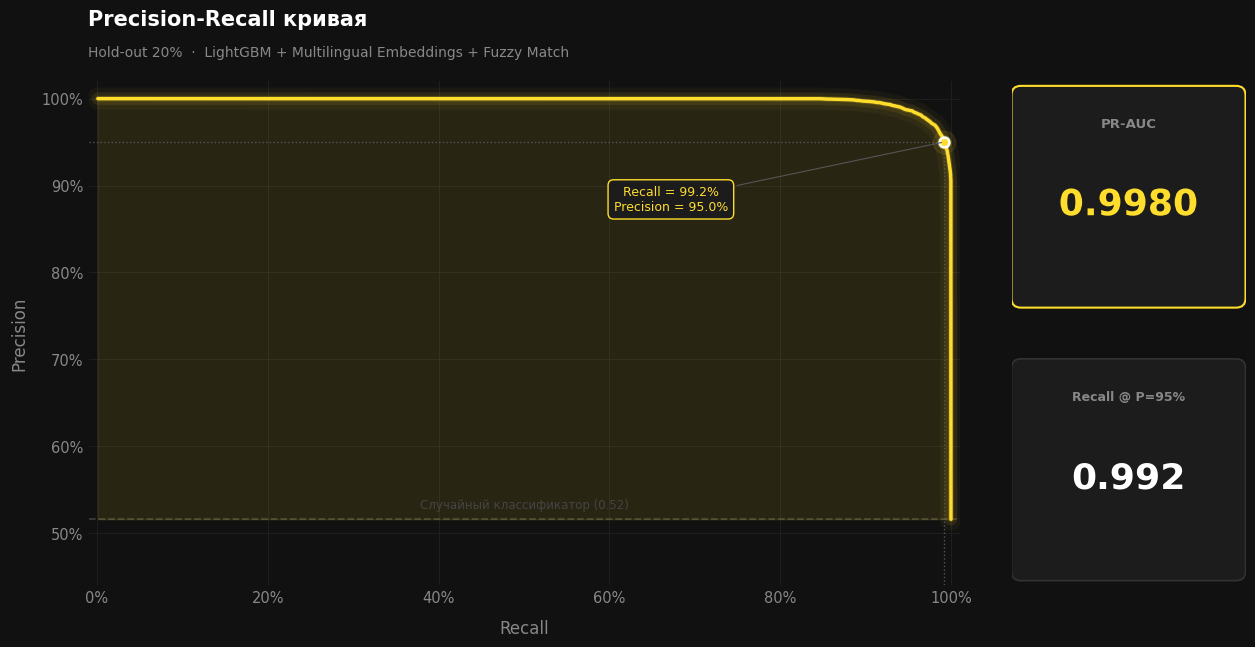

PR-AUC: 0.9980 | Recall @ Precision=95%: 0.9920


In [10]:
# ====================================================
# PR-КРИВАЯ В СТИЛЕ Т-БАНКА
# ====================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patheffects import withStroke
from sklearn.metrics import precision_recall_curve

precision_arr, recall_arr, _ = precision_recall_curve(y_val3, val_pred_v3)
baseline = np.mean(y_val3)

mask = precision_arr[:-1] >= 0.95
if mask.any():
    r95 = float(recall_arr[:-1][mask].max())
    best_idx = int(np.where((recall_arr[:-1] == r95) & mask)[0][-1])
    p95 = float(precision_arr[best_idx])
else:
    r95, p95 = 0.0, 0.95

step = max(1, len(precision_arr) // 1000)
rec  = recall_arr[::step]
prec = precision_arr[::step]

BG, YELLOW, WHITE, GRID, MUTED = '#111111', '#FFDD2D', '#FFFFFF', '#1E1E1E', '#888888'

fig = plt.figure(figsize=(13, 7), facecolor=BG)

ax = fig.add_axes([0.07, 0.13, 0.67, 0.72], facecolor=BG)

for gv in np.arange(0.5, 1.05, 0.1):
    ax.axhline(gv, color=GRID, lw=0.8, zorder=0)
for gh in np.arange(0.0, 1.05, 0.2):
    ax.axvline(gh, color=GRID, lw=0.8, zorder=0)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(0.44, 1.02)

ax.axhline(baseline, color='#3A3A3A', lw=1.3, ls='--', zorder=1)
ax.text(0.50, baseline + 0.013, f'Случайный классификатор ({baseline:.2f})',
        color='#444', fontsize=8.5, ha='center')

ax.fill_between(rec, baseline, prec, alpha=0.10, color=YELLOW, zorder=2)

for lw_, a_ in [(16, 0.04), (9, 0.09), (4, 0.16)]:
    ax.plot(rec, prec, color=YELLOW, lw=lw_, alpha=a_, solid_capstyle='round', zorder=3)
ax.plot(rec, prec, color=YELLOW, lw=2.5, solid_capstyle='round', zorder=4)

ax.plot([r95, r95], [0.44, p95], color='#555', lw=1.0, ls=':', zorder=3)
ax.plot([-0.01, r95], [p95, p95], color='#555', lw=1.0, ls=':', zorder=3)

for s_, a_ in [(260, 0.08), (90, 0.18)]:
    ax.scatter([r95], [p95], s=s_, color=YELLOW, alpha=a_, zorder=5)
ax.scatter([r95], [p95], s=50, color=YELLOW, zorder=6, edgecolors=WHITE, linewidths=1.8)

label_x = max(0.05, r95 - 0.32)
label_y = p95 - 0.05
ax.annotate(
    f'Recall = {r95:.1%}\nPrecision = {p95:.1%}',
    xy=(r95, p95),
    xytext=(label_x, label_y),
    color=YELLOW,
    fontsize=9,
    ha='center',
    va='top',
    arrowprops=dict(arrowstyle='-', color='#555', lw=0.8),
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#1C1C1C',
              edgecolor=YELLOW, linewidth=1.0),
    zorder=8,
)

ax.tick_params(colors=MUTED, labelsize=10.5, length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_xlabel('Recall',    color=MUTED, fontsize=12, labelpad=10)
ax.set_ylabel('Precision', color=MUTED, fontsize=12, labelpad=10)
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%','20%','40%','60%','80%','100%'], color=MUTED)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['50%','60%','70%','80%','90%','100%'], color=MUTED)

cax1 = fig.add_axes([0.78, 0.52, 0.18, 0.33], facecolor=BG)
cax1.set_xlim(0, 1); cax1.set_ylim(0, 1); cax1.axis('off')
c1 = patches.FancyBboxPatch((0.04, 0.06), 0.92, 0.88,
     boxstyle="round,pad=0.04", lw=1.5, edgecolor=YELLOW, facecolor='#1C1C1C')
cax1.add_patch(c1)
cax1.text(0.50, 0.80, 'PR-AUC', ha='center', color=MUTED, fontsize=9.5, fontweight='bold')
cax1.text(0.50, 0.42, f'{pr_auc_v3:.4f}', ha='center', color=YELLOW, fontsize=26, fontweight='bold',
          path_effects=[withStroke(linewidth=4, foreground='#1C1C1C')])

cax2 = fig.add_axes([0.78, 0.13, 0.18, 0.33], facecolor=BG)
cax2.set_xlim(0, 1); cax2.set_ylim(0, 1); cax2.axis('off')
c2 = patches.FancyBboxPatch((0.04, 0.06), 0.92, 0.88,
     boxstyle="round,pad=0.04", lw=1.2, edgecolor='#333', facecolor='#1C1C1C')
cax2.add_patch(c2)
cax2.text(0.50, 0.80, 'Recall @ P=95%', ha='center', color=MUTED, fontsize=9, fontweight='bold')
cax2.text(0.50, 0.42, f'{r95:.3f}', ha='center', color=WHITE, fontsize=26, fontweight='bold')

fig.text(0.07, 0.93,  'Precision-Recall кривая',
         ha='left', color=WHITE, fontsize=15, fontweight='bold')
fig.text(0.07, 0.885, 'Hold-out 20%  ·  LightGBM + Multilingual Embeddings + Fuzzy Match',
         ha='left', color=MUTED, fontsize=10)

plt.savefig('pr_curve_tbank.png', dpi=150, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()  # ← выводим прямо в ячейку
print(f"PR-AUC: {pr_auc_v3:.4f} | Recall @ Precision=95%: {r95:.4f}")


/Users/ruaczcf/myenv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/Users/ruaczcf/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


X_sample: (500, 428), sv_tab: (500, 44)
base_val: 0.0380, tab features: 44


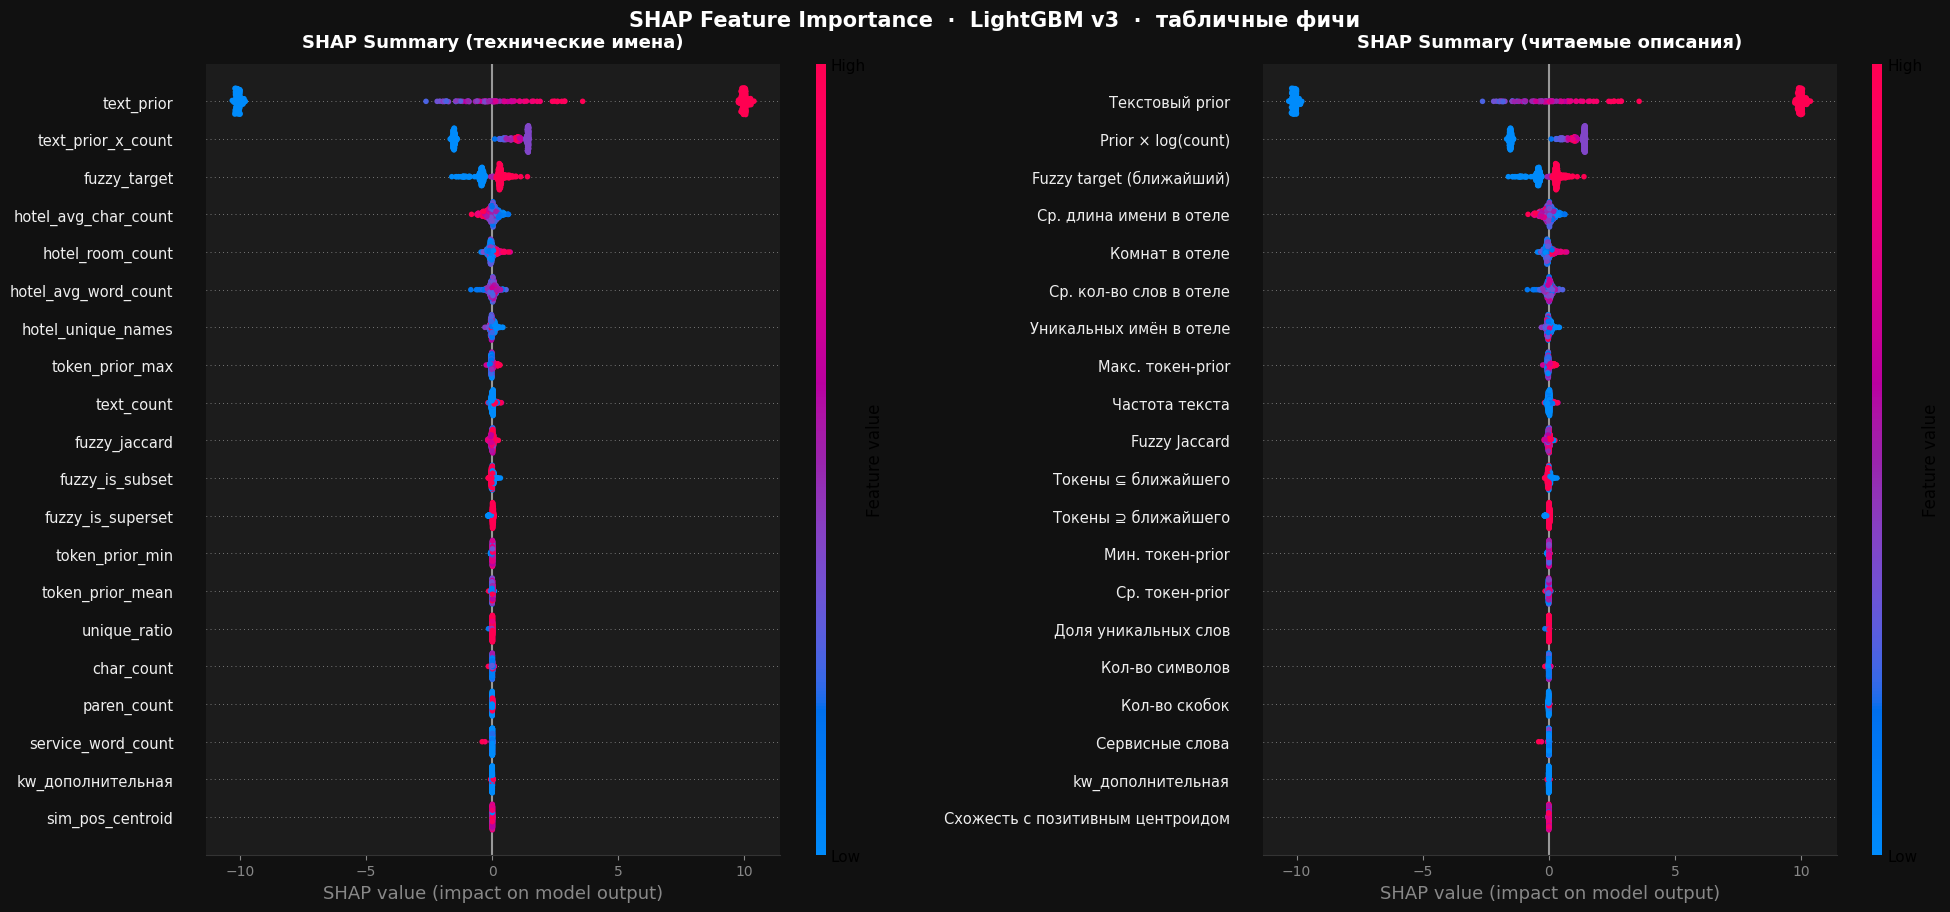

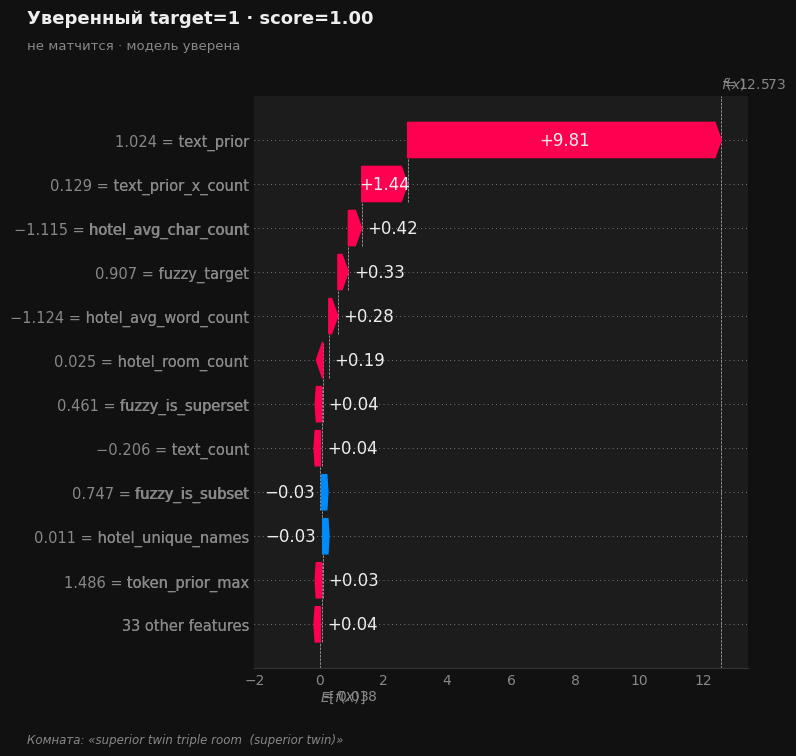

Saved → shap_waterfall_superior twin triple room  (superior twin)_имена.png | room: «superior twin triple room  (superior twin)»


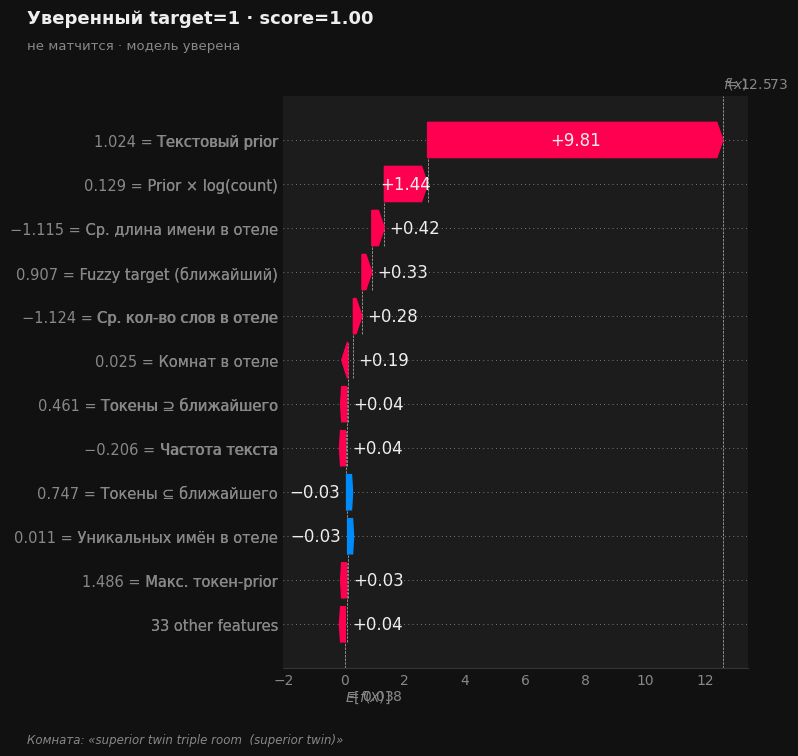

Saved → shap_waterfall_superior twin triple room  (superior twin)_описания.png | room: «superior twin triple room  (superior twin)»


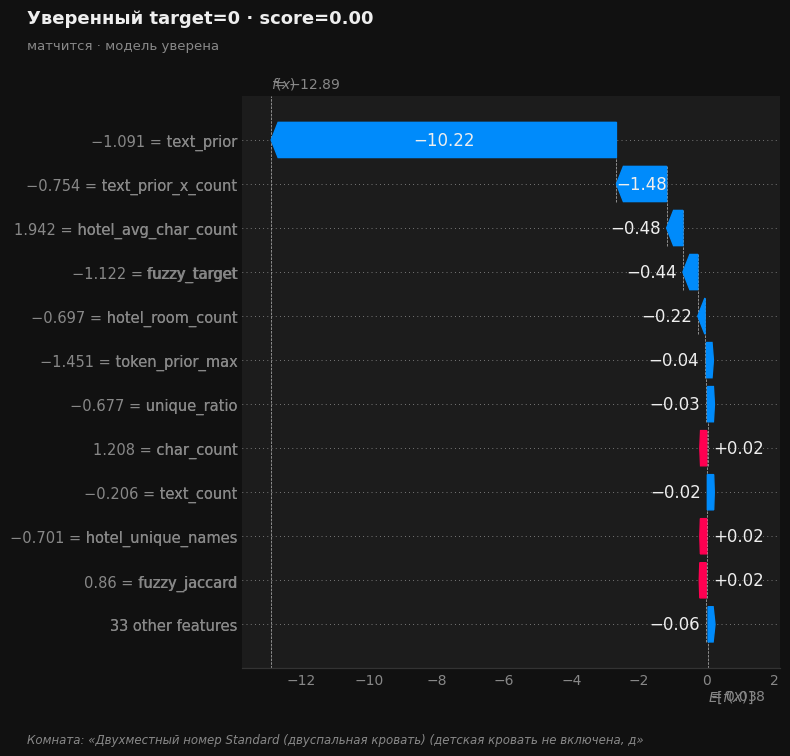

Saved → shap_waterfall_Двухместный номер Standard (двуспальная кровать) (детская кр_имена.png | room: «Двухместный номер Standard (двуспальная кровать) (детская кровать не включена, дополнительные кровати не включены, детская кровать не включена)»


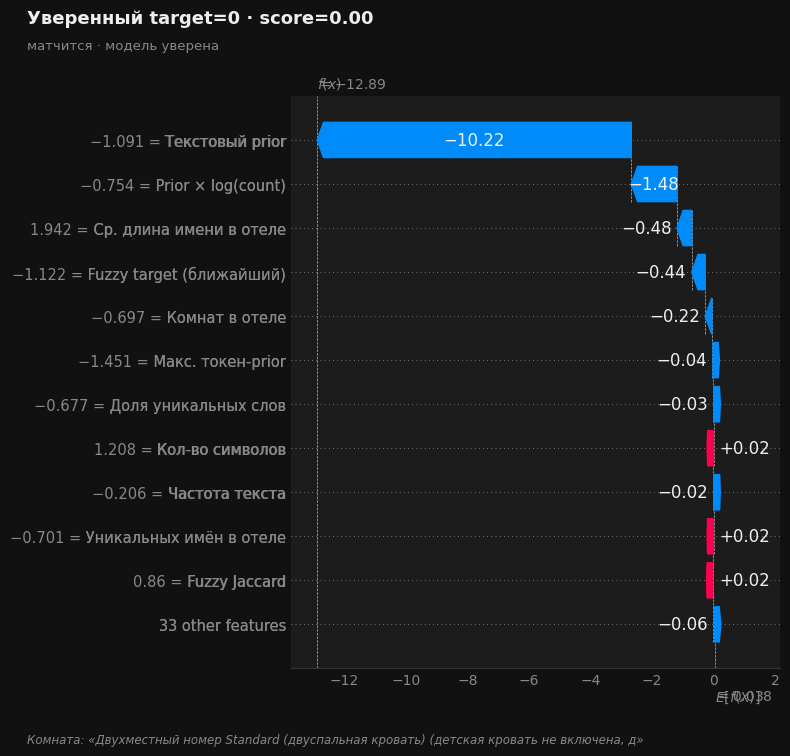

Saved → shap_waterfall_Двухместный номер Standard (двуспальная кровать) (детская кр_описания.png | room: «Двухместный номер Standard (двуспальная кровать) (детская кровать не включена, дополнительные кровати не включены, детская кровать не включена)»


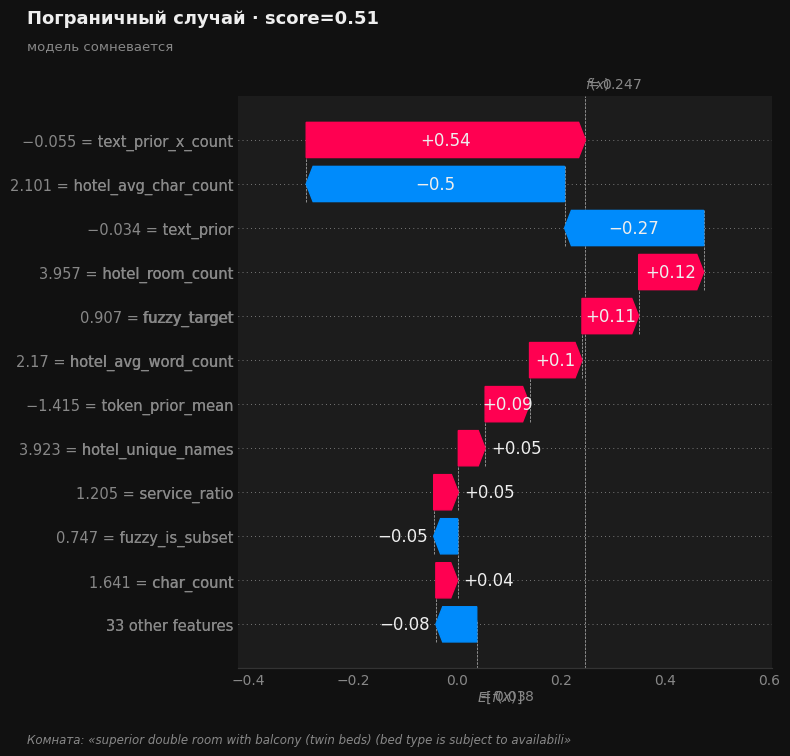

Saved → shap_waterfall_superior double room with balcony (twin beds) (bed type is s_имена.png | room: «superior double room with balcony (twin beds) (bed type is subject to availability child bed not included extra bed not included child bed is not included pool access)»


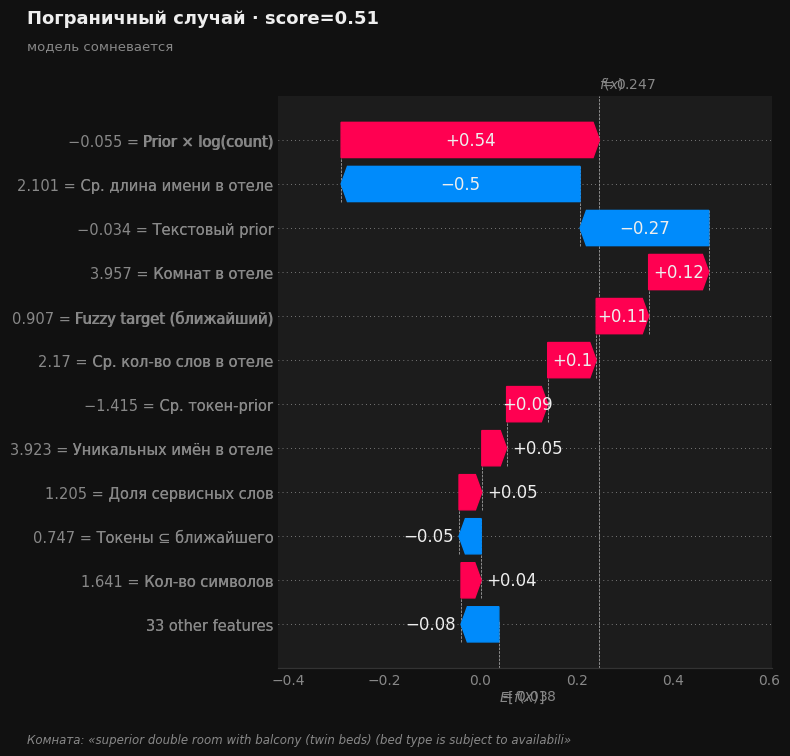

Saved → shap_waterfall_superior double room with balcony (twin beds) (bed type is s_описания.png | room: «superior double room with balcony (twin beds) (bed type is subject to availability child bed not included extra bed not included child bed is not included pool access)»


/var/folders/w7/68yd1vm135q3kvvtyw1cnl6nhws3sm/T/ipykernel_49542/560959462.py:172: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/var/folders/w7/68yd1vm135q3kvvtyw1cnl6nhws3sm/T/ipykernel_49542/560959462.py:172: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


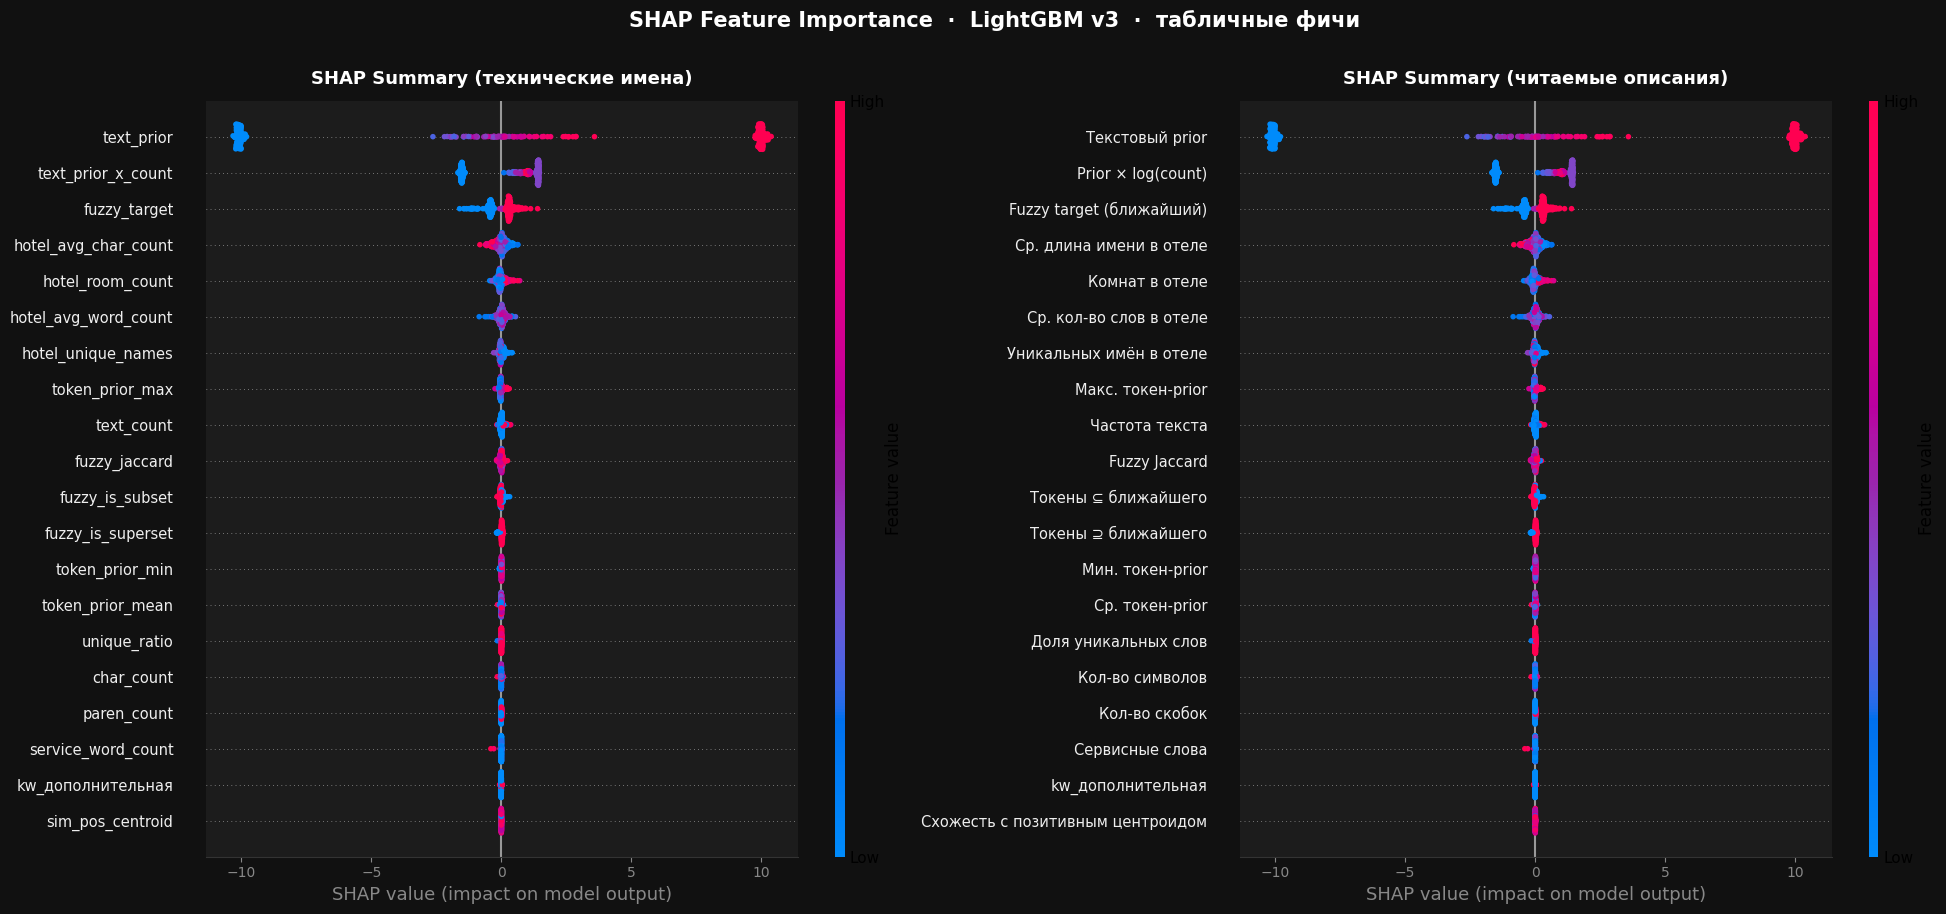

Saved → shap_summary.png


In [13]:
import shap

# ====================================================
# ПОДГОТОВКА СЭМПЛА И SHAP-ЗНАЧЕНИЙ
# ====================================================
SAMPLE_SIZE = 500
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_v3), size=SAMPLE_SIZE, replace=False)
X_sample   = X_train_v3[sample_idx]
y_sample   = y[sample_idx]

# Размерность эмбеддингов
emb_dim = train_emb.shape[1]  # 384 для MiniLM-L12-v2

# Имена табличных фичей
tab_names = X_train_tab_v3.columns.tolist()

# Читаемые описания (для второго прохода)
desc_map = {
    "word_count": "Кол-во слов",
    "char_count": "Кол-во символов",
    "paren_count": "Кол-во скобок",
    "has_number": "Есть цифры",
    "has_latin": "Есть латиница",
    "has_cyrillic": "Есть кириллица",
    "unique_ratio": "Доля уникальных слов",
    "service_word_count": "Сервисные слова",
    "room_word_count": "Слова типа номера",
    "paren_len": "Длина скобочного блока",
    "service_ratio": "Доля сервисных слов",
    "hotel_room_count": "Комнат в отеле",
    "hotel_unique_names": "Уникальных имён в отеле",
    "hotel_avg_word_count": "Ср. кол-во слов в отеле",
    "hotel_avg_char_count": "Ср. длина имени в отеле",
    "text_prior": "Текстовый prior",
    "text_count": "Частота текста",
    "text_prior_x_count": "Prior × log(count)",
    "token_prior_mean": "Ср. токен-prior",
    "token_prior_max": "Макс. токен-prior",
    "token_prior_min": "Мин. токен-prior",
    "sim_pos_centroid": "Схожесть с позитивным центроидом",
    "sim_neg_centroid": "Схожесть с негативным центроидом",
    "sim_margin": "Margin (pos − neg centroid)",
    "service_minus_room": "Сервис − тип номера",
    "fuzzy_jaccard": "Fuzzy Jaccard",
    "fuzzy_target": "Fuzzy target (ближайший)",
    "fuzzy_is_subset": "Токены ⊆ ближайшего",
    "fuzzy_is_superset": "Токены ⊇ ближайшего",
}
tab_descs = [desc_map.get(n, n) for n in tab_names]

# SHAP: TreeExplainer на модели v3
explainer = shap.TreeExplainer(model_v3)
sv_all = explainer.shap_values(X_sample)

# LightGBM бинарная классификация: sv_all — список [neg, pos] или один массив
if isinstance(sv_all, list):
    sv_all   = sv_all[1]
    base_val = float(explainer.expected_value[1])
else:
    base_val = float(explainer.expected_value)

# Только табличная часть SHAP (без эмбеддинг-колонок)
sv_tab = sv_all[:, emb_dim:]

print(f"X_sample: {X_sample.shape}, sv_tab: {sv_tab.shape}")
print(f"base_val: {base_val:.4f}, tab features: {len(tab_names)}")

# ====================================================
# WATERFALL PLOTS
# ====================================================
BG, CARD, BORDER, DARK, MUTED = '#111111', '#1C1C1C', '#333333', '#EEEEEE', '#888888'

pred_scores = model_v3.predict_proba(X_sample)[:, 1]
idx_pos  = np.where(y_sample == 1)[0]
idx_neg  = np.where(y_sample == 0)[0]
sure_pos = idx_pos[np.argmax(pred_scores[idx_pos])]
sure_neg = idx_neg[np.argmin(pred_scores[idx_neg])]
border   = np.argmin(np.abs(pred_scores - 0.5))


def get_room_name(local_idx):
    train_idx = sample_idx[local_idx]
    return str(train.iloc[train_idx]["supplier_room_name"])


cases = [
    (sure_pos, f"Уверенный target=1 · score={pred_scores[sure_pos]:.2f}", "не матчится · модель уверена"),
    (sure_neg, f"Уверенный target=0 · score={pred_scores[sure_neg]:.2f}", "матчится · модель уверена"),
    (border,   f"Пограничный случай · score={pred_scores[border]:.2f}",   "модель сомневается"),
]


def fix_waterfall_overlaps(fig):
    fig.patch.set_facecolor(BG)
    for ax in fig.axes:
        ax.set_facecolor(CARD)
        for sp in ax.spines.values(): sp.set_color(BORDER)
        for txt in ax.texts:             txt.set_color(DARK)
        for txt in ax.get_xticklabels(): txt.set_color(MUTED); txt.set_fontsize(10)
        for txt in ax.get_yticklabels(): txt.set_color(DARK);  txt.set_fontsize(10.5)
        ax.xaxis.label.set_color(MUTED)
        ax.tick_params(colors=MUTED, length=0)

    fig.canvas.draw()
    annots = [t for t in fig.texts if 'f(x)' in t.get_text() or 'E[f' in t.get_text()]
    if len(annots) == 2:
        t0, t1 = annots[0], annots[1]
        y0, y1 = t0.get_position()[1], t1.get_position()[1]
        if abs(y0 - y1) < 0.045:
            mid, offset = (y0 + y1) / 2, 0.025
            if y0 >= y1:
                t0.set_position((t0.get_position()[0], mid + offset))
                t1.set_position((t1.get_position()[0], mid - offset))
            else:
                t1.set_position((t1.get_position()[0], mid + offset))
                t0.set_position((t0.get_position()[0], mid - offset))


def style_waterfall_title(fig, title, subtitle):
    fig.text(0.04, 0.97,  title,    ha='left', color=DARK,  fontsize=13, fontweight='bold')
    fig.text(0.04, 0.935, subtitle, ha='left', color=MUTED, fontsize=9.5)


for case_idx, title, subtitle in cases:
    room_name = get_room_name(case_idx)
    safe_room = (room_name
                 .replace('/', '_').replace('\\', '_').replace(':', '')
                 .replace('"', '').replace('*', '').replace('?', '')
                 .replace('<', '').replace('>', '').replace('|', '').strip())[:60]

    for feat_names, suffix in [
        (tab_names, "имена"),
        (tab_descs, "описания"),
    ]:
        shap_exp = shap.Explanation(
            values        = sv_tab[case_idx],
            base_values   = base_val,
            data          = X_sample[case_idx, emb_dim:],
            feature_names = feat_names,
        )

        plt.figure(figsize=(13, 6.5))
        shap.waterfall_plot(shap_exp, max_display=12, show=False)
        fig = plt.gcf()

        fix_waterfall_overlaps(fig)
        style_waterfall_title(fig, title, subtitle)
        fig.text(0.04, 0.01,
                 f'Комната: «{room_name[:80]}»',
                 ha='left', color=MUTED, fontsize=8.5, style='italic')

        plt.tight_layout(rect=[0, 0.04, 1, 0.92])

        fname = f"shap_waterfall_{safe_room}_{suffix}.png"
        plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
        plt.show()  # ← выводим прямо в ячейку
        plt.close()
        print(f"Saved → {fname} | room: «{room_name}»")

# ====================================================
# SHAP SUMMARY PLOT (полный, по всем табличным фичам)
# ====================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor=BG)

for ax, feat_names, title_suffix in zip(
    axes,
    [tab_names, tab_descs],
    ["(технические имена)", "(читаемые описания)"]
):
    plt.sca(ax)
    shap.summary_plot(
        sv_tab,
        features      = X_sample[:, emb_dim:],
        feature_names = feat_names,
        max_display   = 20,
        show          = False,
        plot_size     = None,
    )
    ax.set_facecolor(CARD)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.tick_params(colors=MUTED, labelsize=10)
    ax.xaxis.label.set_color(MUTED)
    for txt in ax.get_yticklabels(): txt.set_color(DARK); txt.set_fontsize(10.5)
    ax.set_title(
        f"SHAP Summary {title_suffix}",
        color=WHITE, fontsize=13, fontweight='bold', pad=12
    )

fig.patch.set_facecolor(BG)
fig.suptitle(
    "SHAP Feature Importance  ·  LightGBM v3  ·  табличные фичи",
    color=WHITE, fontsize=15, fontweight='bold', y=1.01
)

# Перекрашиваем colorbar (добавляется автоматически shap'ом)
# Перекрашиваем colorbar (добавляется автоматически shap'ом)
for ax in axes:
    for child in ax.get_children():
        if hasattr(child, 'colorbar') and child.colorbar is not None:
            child.colorbar.ax.tick_params(colors=MUTED)


plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()
print("Saved → shap_summary.png")

